In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Data/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.shape

(7043, 21)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
df.drop(columns = ['customerID'], inplace=True)

In [7]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [9]:
df['gender'].value_counts()

gender
Male      3555
Female    3488
Name: count, dtype: int64

In [10]:
for col in df.columns:
    if col not in ['tenure', 'MonthlyCharges', 'TotalCharges']:
        print(col, df[col].unique())
        print("----------")

gender <StringArray>
['Female', 'Male']
Length: 2, dtype: str
----------
SeniorCitizen [0 1]
----------
Partner <StringArray>
['Yes', 'No']
Length: 2, dtype: str
----------
Dependents <StringArray>
['No', 'Yes']
Length: 2, dtype: str
----------
PhoneService <StringArray>
['No', 'Yes']
Length: 2, dtype: str
----------
MultipleLines <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
----------
InternetService <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
----------
OnlineSecurity <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
----------
OnlineBackup <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
----------
DeviceProtection <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
----------
TechSupport <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
----------
StreamingTV <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
----------
Strea

In [11]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [12]:
for col in ['tenure', 'MonthlyCharges', 'TotalCharges']:
    print(col, len(df[df[col]== " "]))
    print("-------------------------------------")

tenure 0
-------------------------------------
MonthlyCharges 0
-------------------------------------
TotalCharges 11
-------------------------------------


In [13]:
df['TotalCharges'] = df['TotalCharges'].replace({" ": "0.0"}).astype(float)

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [15]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [17]:
def plot_distribution(df, column):
    
    # Create figure
    plt.figure(figsize=(12, 5))

    # ---------------- Histogram ----------------
    plt.subplot(1, 2, 1)

    sns.histplot(
        data=df,
        x=column,
        kde=True
    )

    # Mean and Median
    mean_value = df[column].mean()
    median_value = df[column].median()

    plt.axvline(
        mean_value,
        color='red',
        linestyle='--',
        linewidth=2,
        label=f"Mean : {mean_value:.2f}"
    )

    plt.axvline(
        median_value,
        color='blue',
        linestyle='--',
        linewidth=2,
        label=f"Median : {median_value:.2f}"
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.legend()

    # ---------------- Boxplot ----------------
    plt.subplot(1, 2, 2)

    sns.boxplot(
        y=df[column]
    )

    plt.title(f"Boxplot of {column}")
    plt.ylabel(column)

    plt.tight_layout()
    plt.show()

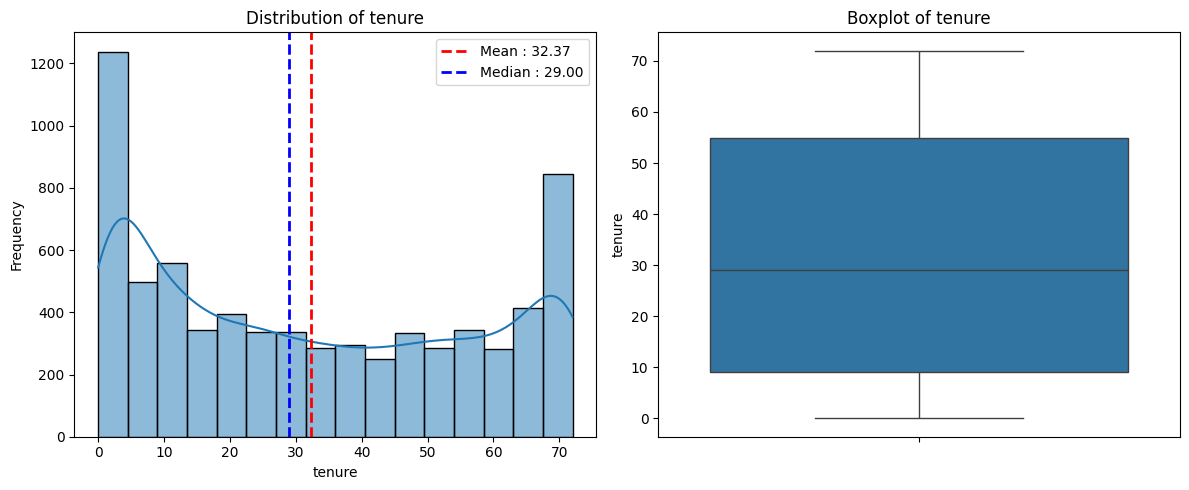

In [18]:
plot_distribution(df, "tenure")


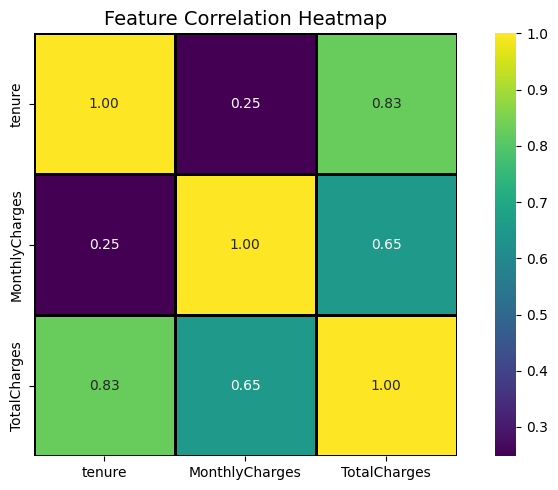

In [20]:
corr_data = df[['tenure', 'MonthlyCharges', 'TotalCharges']]
corr_matrix = corr_data.corr()

plt.figure(figsize=(8, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='viridis',
    linewidths=1,
    linecolor='black',
    square=True,
    cbar=True,
    fmt='.2f'
)

plt.title("Feature Correlation Heatmap", fontsize=14)

plt.tight_layout()
plt.show()

C:\Users\gowth\AppData\Local\Temp\ipykernel_4560\3419052548.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include='object').columns


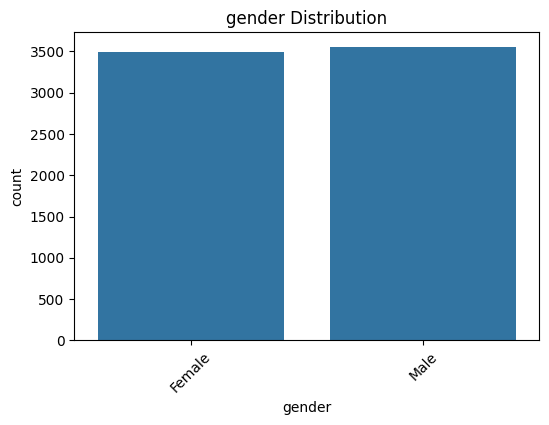

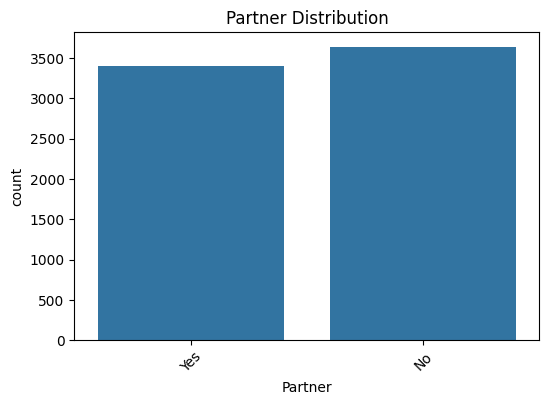

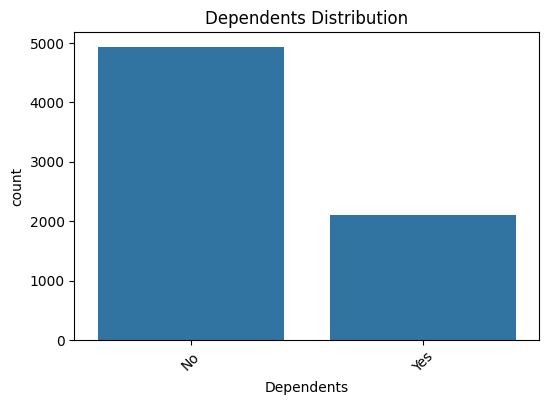

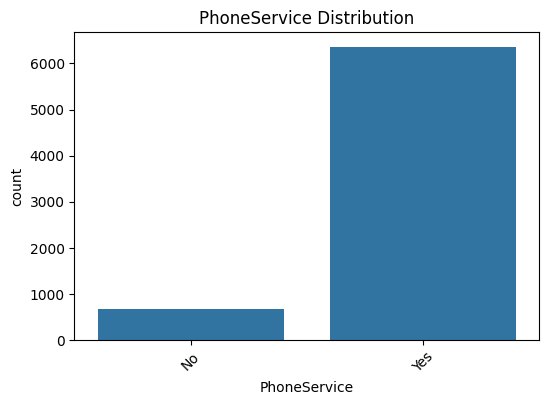

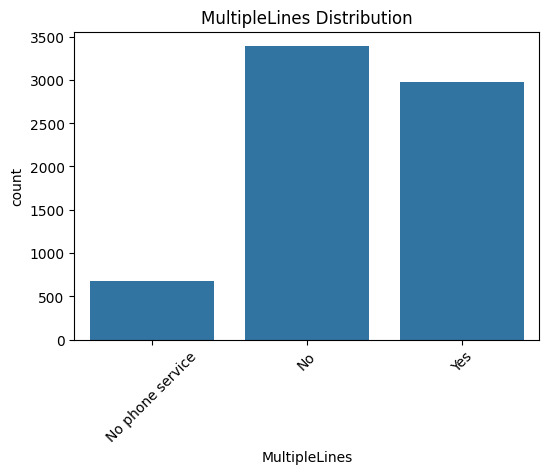

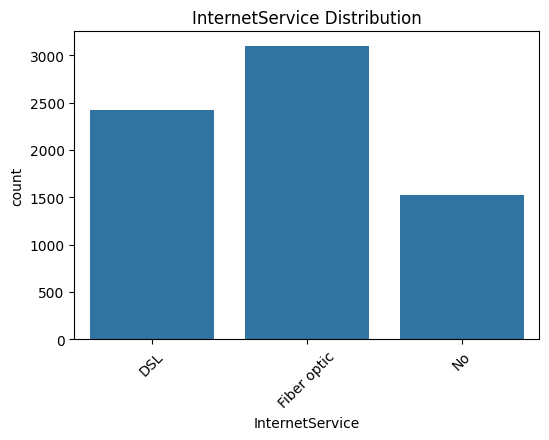

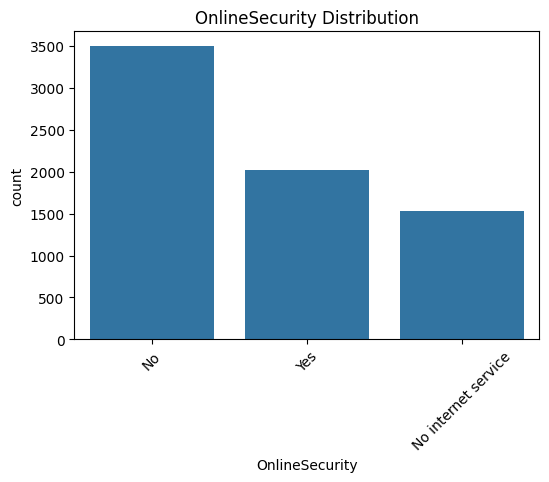

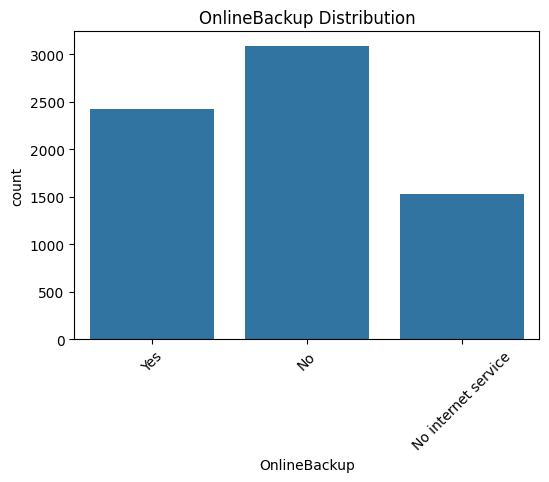

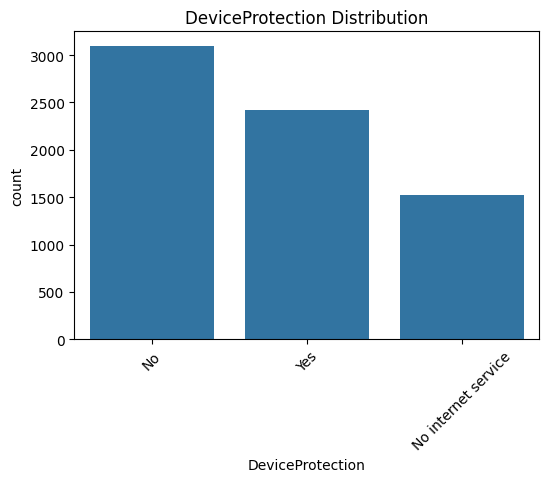

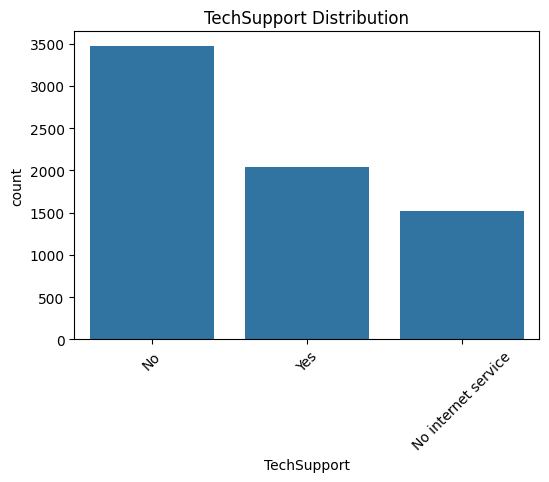

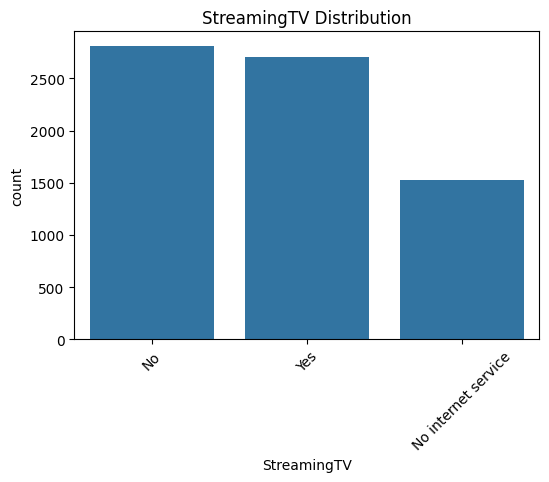

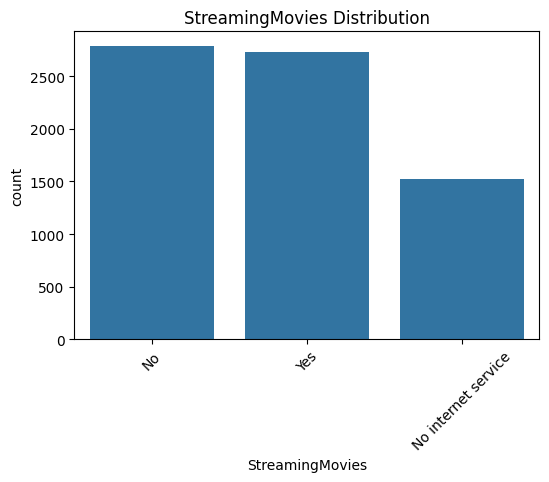

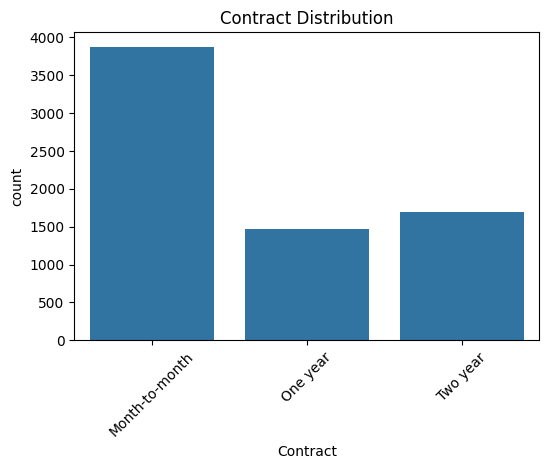

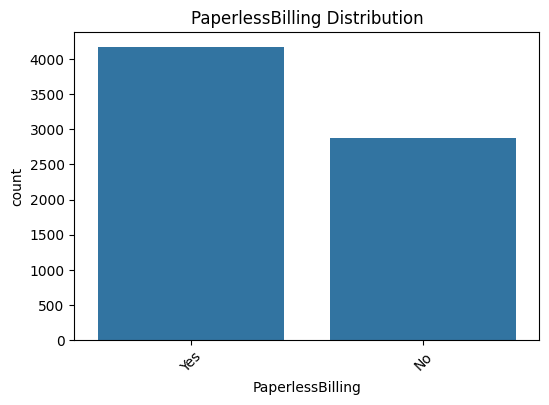

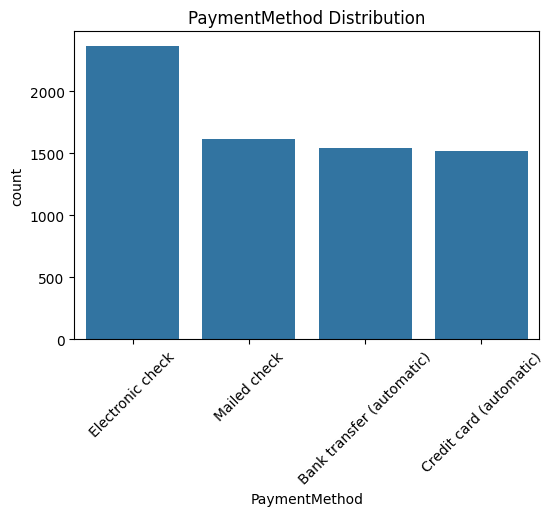

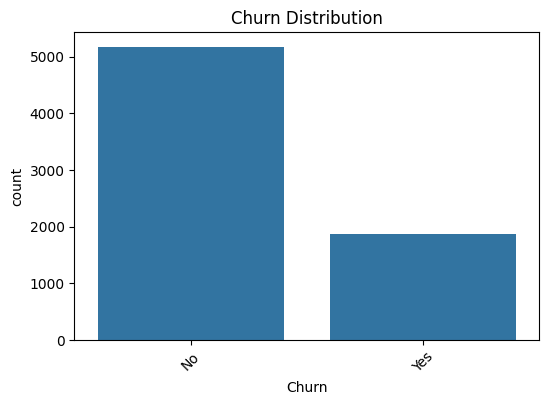

In [21]:

categorical_cols = df.select_dtypes(include='object').columns

for col in categorical_cols:

    plt.figure(figsize=(6, 4))

    sns.countplot(x=df[col])

    plt.title(f"{col} Distribution")

    plt.xticks(rotation=45)

    plt.show()

In [22]:

# Label Encoding

df['Churn'] = df['Churn'].replace({"Yes": 1, "No": 0})

In [23]:

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [24]:
obj_col= df.select_dtypes(include = "object").columns


C:\Users\gowth\AppData\Local\Temp\ipykernel_4560\1232994426.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  obj_col= df.select_dtypes(include = "object").columns


In [25]:
obj_col

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'Churn'],
      dtype='str')

In [28]:
%pip install scikit-learn


  Obtaining dependency information for scikit-learn from https://files.pythonhosted.org/packages/89/3c/45c352094cfa60050bcbb967b1faf246b22e93cb459f2f907b600f2ceda5/scikit_learn-1.8.0-cp311-cp311-win_amd64.whl.metadata
  Obtaining dependency information for joblib>=1.3.0 from https://files.pythonhosted.org/packages/7b/91/984aca2ec129e2757d1e4e3c81c3fcda9d0f85b74670a094cc443d9ee949/joblib-1.5.3-py3-none-any.whl.metadata
  Obtaining dependency information for threadpoolctl>=3.2.0 from https://files.pythonhosted.org/packages/32/d5/f9a850d79b0851d1d4ef6456097579a9005b31fea68726a4ae5f2d82ddd9/threadpoolctl-3.6.0-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
    --------------------------------------- 0.1/8.1 MB 1.5 MB/s eta 0:00:06
   - -------------------------------------- 0.3/8.1 MB 2.7 MB/s eta 0:00:03
   -- ------------------------------------- 0.5/8.1 MB 2.8 MB/s eta 0


[notice] A new release of pip is available: 23.2.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:

from sklearn.preprocessing import LabelEncoder

encoders = {}

for column in obj_col:
    label_encoder = LabelEncoder()
    df[column] = label_encoder.fit_transform(df[column])
    encoders[column] = label_encoder

In [31]:
encoders

{'gender': LabelEncoder(),
 'Partner': LabelEncoder(),
 'Dependents': LabelEncoder(),
 'PhoneService': LabelEncoder(),
 'MultipleLines': LabelEncoder(),
 'InternetService': LabelEncoder(),
 'OnlineSecurity': LabelEncoder(),
 'OnlineBackup': LabelEncoder(),
 'DeviceProtection': LabelEncoder(),
 'TechSupport': LabelEncoder(),
 'StreamingTV': LabelEncoder(),
 'StreamingMovies': LabelEncoder(),
 'Contract': LabelEncoder(),
 'PaperlessBilling': LabelEncoder(),
 'PaymentMethod': LabelEncoder(),
 'Churn': LabelEncoder()}

In [33]:
#Save Encoders 
import pickle

with open("encoder.pkl", "wb") as f:
    pickle.dump(encoders, f)

print("encoder.pkl saved")

encoder.pkl saved


In [34]:
# Standard Scaling

from sklearn.preprocessing import StandardScaler

numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
df[numerical_cols] = scaler.fit_transform(df[numerical_cols])

print("Scaling done")
print(df[numerical_cols].head())

Scaling done
     tenure  MonthlyCharges  TotalCharges
0 -1.277445       -1.160323     -0.992611
1  0.066327       -0.259629     -0.172165
2 -1.236724       -0.362660     -0.958066
3  0.514251       -0.746535     -0.193672
4 -1.236724        0.197365     -0.938874


In [36]:
%pip install imbalanced-learn

  Obtaining dependency information for imbalanced-learn from https://files.pythonhosted.org/packages/c7/b5/56f1ceb568676c0231d12b2fed17ebfd606dd1f627e7372aaed5dd56bd97/imbalanced_learn-0.14.1-py3-none-any.whl.metadata
  Obtaining dependency information for sklearn-compat<0.2,>=0.1.5 from https://files.pythonhosted.org/packages/53/60/08cb1b41563a0a8f26a72b8c5d1726986ab535fee67aa95541b2a2cc1dfa/sklearn_compat-0.1.5-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/235.4 kB ? eta -:--:--
   - -------------------------------------- 10.2/235.4 kB ? eta -:--:--
   ----------------- ---------------------- 102.4/235.4 kB 1.5 MB/s eta 0:00:01
   ---------------------------------------- 235.4/235.4 kB 2.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [37]:
# Handle Class Imbalance with SMOTE + Train/Test Split

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

X = df.drop(columns=['Churn'])
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Before SMOTE:")
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Churn
0    4138
1    1496
Name: count, dtype: int64

After SMOTE:
Churn
0    4138
1    4138
Name: count, dtype: int64
